# Task 1: Air Quality Forecasting

## Problem Statement

The objective of this project is to analyze historical air-quality measurements and build a machine learning model to predict a future air-quality measurement.

## Dataset

UCI Air Quality Dataset

## Objectives

* Understand and preprocess the dataset.
* Perform exploratory data analysis and visualize trends.
* Create meaningful time-based features.
* Build and evaluate a forecasting model.
* Analyze the results, limitations, and possible improvements.


In [9]:
!wget -q "https://archive.ics.uci.edu/static/public/360/air+quality.zip" -O air_quality.zip
!unzip -o air_quality.zip

Archive:  air_quality.zip
  inflating: AirQualityUCI.csv       
  inflating: AirQualityUCI.xlsx      


In [10]:
import os

print(os.listdir())

['.config', 'AirQualityUCI.csv', 'air_quality.zip', 'AirQualityUCI.xlsx', 'sample_data']


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(
    "AirQualityUCI.csv",
    sep=";",
    decimal=","
)

# Remove completely empty columns
df = df.dropna(axis=1, how="all")

# Display the first five rows
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [12]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

print("\nFirst 5 rows:")
display(df.head())

print("\nBasic statistics:")
display(df.describe(include="all"))

Dataset shape: (9471, 15)

Column names:
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

Data types:
Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   flo

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888



Basic statistics:


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357,9357,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
unique,391,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,03/04/2005,18.00.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,24,390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,NaN,NaN,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,NaN,NaN,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,NaN,NaN,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,NaN,NaN,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,NaN,NaN,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200


In [13]:
# Remove completely empty rows
df = df.dropna(how="all").copy()

# Replace -200 with NaN in measurement columns
measurement_cols = df.select_dtypes(include="number").columns
df[measurement_cols] = df[measurement_cols].replace(-200, np.nan)

# Convert Date and Time into a datetime column
df["DateTime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"].str.replace(".", ":", regex=False),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

# Sort data chronologically
df = df.dropna(subset=["DateTime"]).sort_values("DateTime").reset_index(drop=True)

print("Cleaned dataset shape:", df.shape)
print("\nMissing values in each column:")
print(df.isna().sum())

display(df.head())

Cleaned dataset shape: (9357, 16)

Missing values in each column:
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
DateTime            0
dtype: int64


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,DateTime
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03-10 18:00:00
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004-03-10 19:00:00
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03-10 20:00:00
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2004-03-10 21:00:00
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2004-03-10 22:00:00


Missing values (%):
NMHC(GT)         90.23
CO(GT)           17.99
NO2(GT)          17.55
NOx(GT)          17.52
C6H6(GT)          3.91
PT08.S2(NMHC)     3.91
PT08.S3(NOx)      3.91
PT08.S1(CO)       3.91
T                 3.91
RH                3.91
PT08.S4(NO2)      3.91
PT08.S5(O3)       3.91
AH                3.91
Date              0.00
Time              0.00
DateTime          0.00
dtype: float64


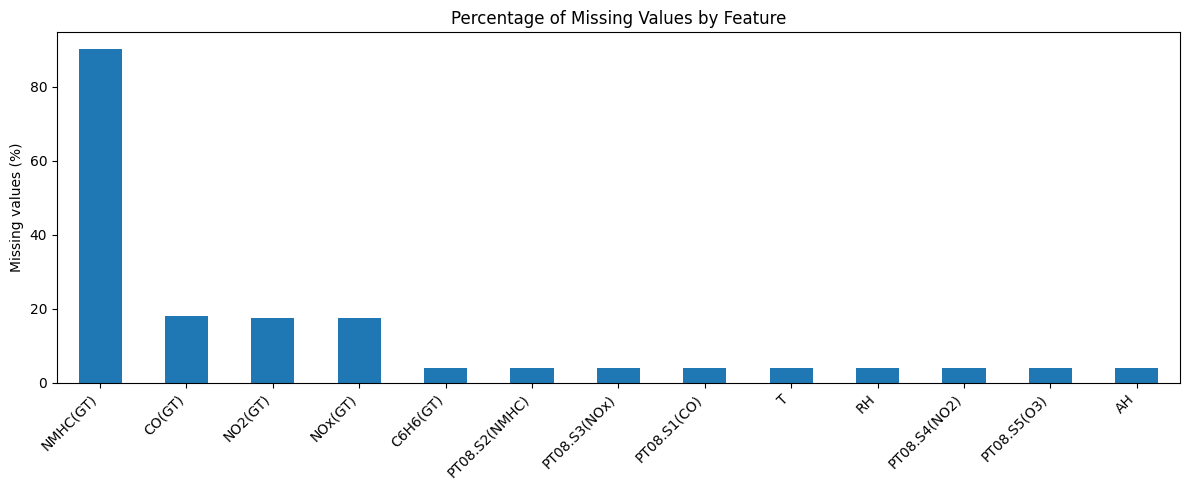

In [14]:
# Calculate missing-value percentages
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

print("Missing values (%):")
print(missing_percent.round(2))

# Plot missing values
missing_percent.drop(["Date", "Time", "DateTime"]).plot(
    kind="bar",
    figsize=(12, 5),
    title="Percentage of Missing Values by Feature",
    ylabel="Missing values (%)"
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

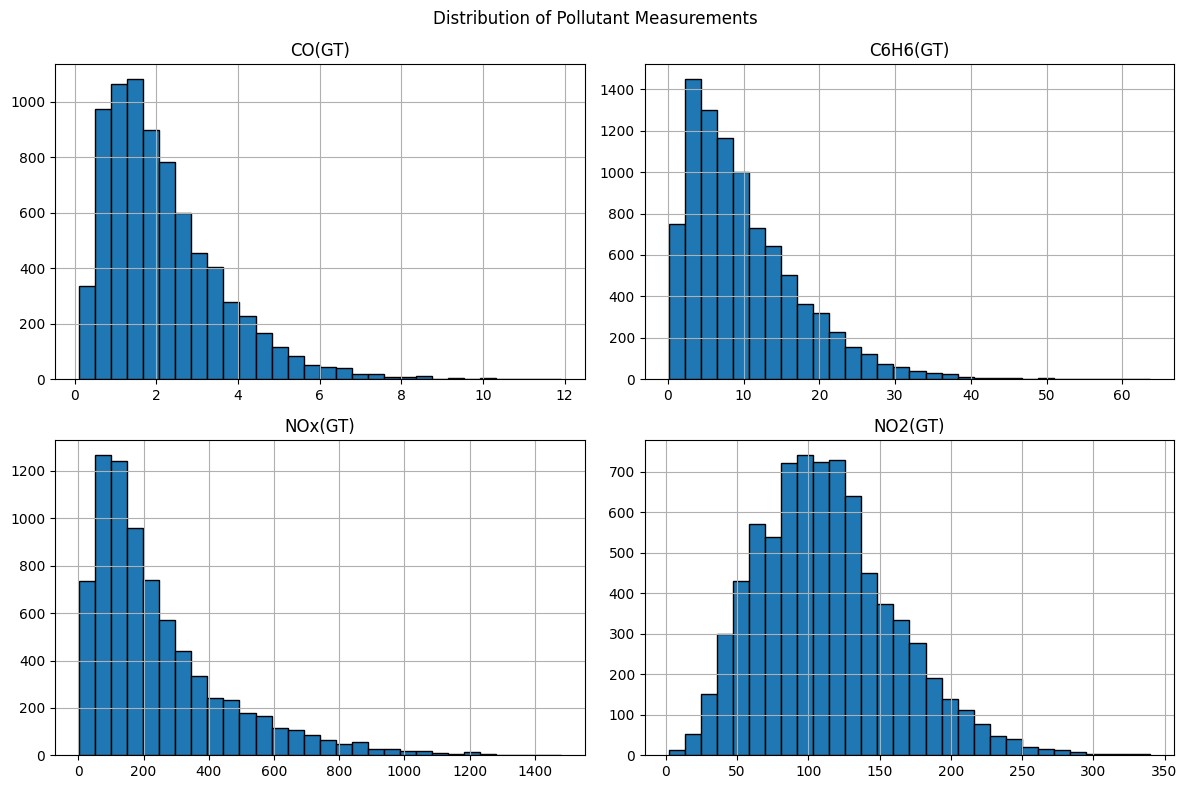

In [15]:
pollutants = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]

df[pollutants].hist(
    bins=30,
    figsize=(12, 8),
    edgecolor="black"
)

plt.suptitle("Distribution of Pollutant Measurements")
plt.tight_layout()
plt.show()

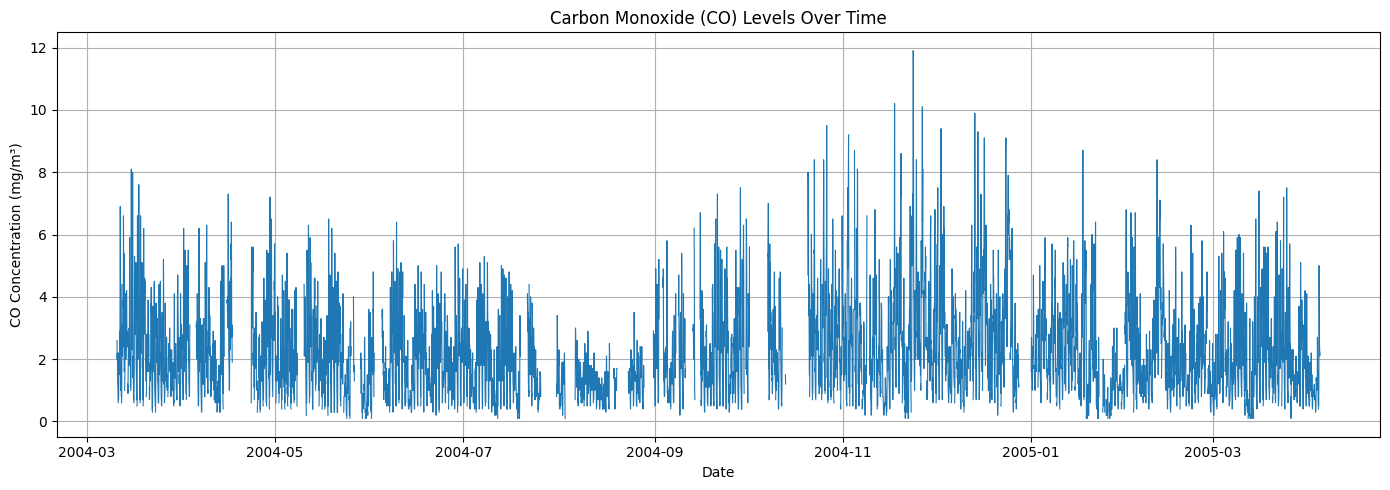

In [16]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["DateTime"],
    df["CO(GT)"],
    linewidth=0.8
)

plt.title("Carbon Monoxide (CO) Levels Over Time")
plt.xlabel("Date")
plt.ylabel("CO Concentration (mg/m³)")
plt.grid(True)
plt.tight_layout()
plt.show()

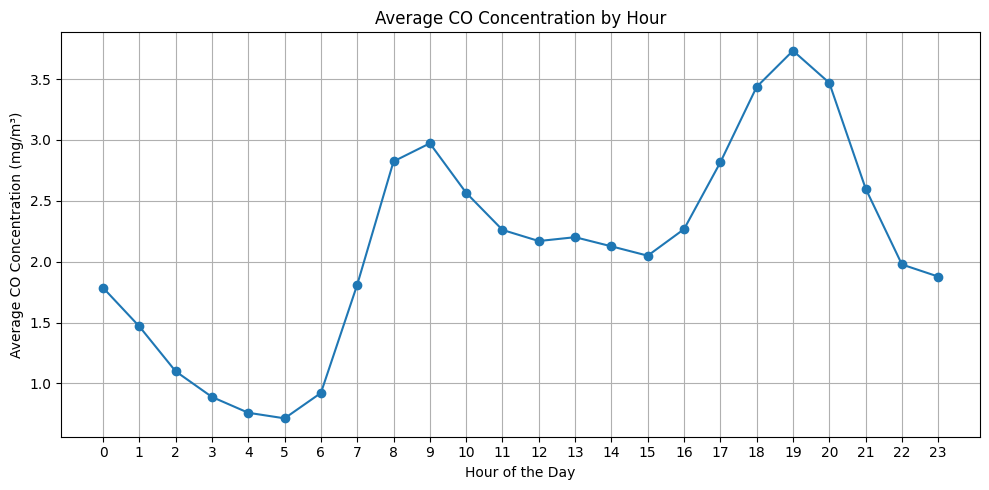

In [17]:
# Extract hour from timestamp
df["Hour"] = df["DateTime"].dt.hour

# Average CO concentration for each hour
hourly_co = df.groupby("Hour")["CO(GT)"].mean()

plt.figure(figsize=(10, 5))

hourly_co.plot(kind="line", marker="o")

plt.title("Average CO Concentration by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Average CO Concentration (mg/m³)")
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

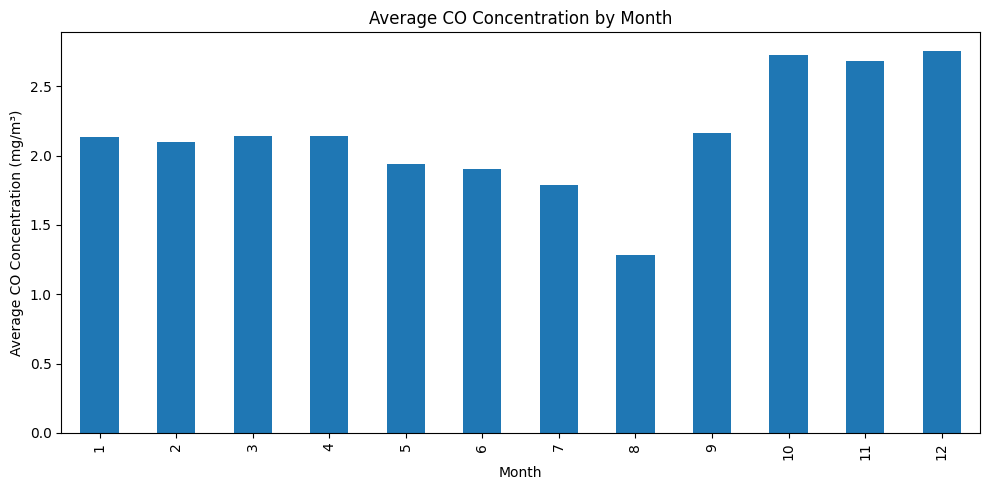

In [18]:
df["Month"] = df["DateTime"].dt.month

monthly_co = df.groupby("Month")["CO(GT)"].mean()

plt.figure(figsize=(10, 5))

monthly_co.plot(kind="bar")

plt.title("Average CO Concentration by Month")
plt.xlabel("Month")
plt.ylabel("Average CO Concentration (mg/m³)")
plt.tight_layout()
plt.show()

In [19]:
# Create a copy for forecasting
data = df.copy()

# Extract time-based features
data["Hour"] = data["DateTime"].dt.hour
data["Day"] = data["DateTime"].dt.day
data["Month"] = data["DateTime"].dt.month
data["DayOfWeek"] = data["DateTime"].dt.dayofweek

# Create lag features using past CO measurements
data["CO_lag1"] = data["CO(GT)"].shift(1)
data["CO_lag2"] = data["CO(GT)"].shift(2)
data["CO_lag3"] = data["CO(GT)"].shift(3)

# Create a rolling average using previous measurements only
data["CO_rolling3"] = (
    data["CO(GT)"].shift(1).rolling(window=3).mean()
)

# Target: CO concentration in the next hour
data["Target"] = data["CO(GT)"].shift(-1)

display(data[[
    "DateTime", "CO(GT)", "CO_lag1", "CO_lag2",
    "CO_lag3", "CO_rolling3", "Target"
]].head(10))

,DateTime,CO(GT),CO_lag1,CO_lag2,CO_lag3,CO_rolling3,Target
0,2004-03-10 18:00:00,2.6,NaN,NaN,NaN,NaN,2.0
1,2004-03-10 19:00:00,2.0,2.6,NaN,NaN,NaN,2.2
2,2004-03-10 20:00:00,2.2,2.0,2.6,NaN,NaN,2.2
3,2004-03-10 21:00:00,2.2,2.2,2.0,2.6,2.266667,1.6
4,2004-03-10 22:00:00,1.6,2.2,2.2,2.0,2.133333,1.2
5,2004-03-10 23:00:00,1.2,1.6,2.2,2.2,2.000000,1.2
6,2004-03-11 00:00:00,1.2,1.2,1.6,2.2,1.666667,1.0
7,2004-03-11 01:00:00,1.0,1.2,1.2,1.6,1.333333,0.9
8,2004-03-11 02:00:00,0.9,1.0,1.2,1.2,1.133333,0.6
9,2004-03-11 03:00:00,0.6,0.9,1.0,1.2,1.033333,NaN


In [20]:
features = [
    "Hour", "Day", "Month", "DayOfWeek",
    "CO_lag1", "CO_lag2", "CO_lag3", "CO_rolling3",
    "PT08.S1(CO)", "C6H6(GT)", "NOx(GT)", "NO2(GT)",
    "T", "RH", "AH"
]

X = data[features]
y = data["Target"]

print("Feature dataset shape:", X.shape)
print("Target shape:", y.shape)

Feature dataset shape: (9357, 15)
Target shape: (9357,)


In [21]:
from sklearn.model_selection import train_test_split

# Remove rows where the target is missing
valid = y.notna()

X = X.loc[valid]
y = y.loc[valid]

# Chronological 80-20 split
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 6138
Testing samples: 1535


In [22]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [23]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Generate predictions
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("MAE:", round(mae, 4))
print("MSE:", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R² Score:", round(r2, 4))

Model Evaluation Results
------------------------
MAE: 0.4709
MSE: 0.4548
RMSE: 0.6744
R² Score: 0.7484


In [24]:
results = pd.DataFrame({
    "Actual CO": y_test,
    "Predicted CO": y_pred
})

display(results.head(10))

,Actual CO,Predicted CO
7788,0.5,0.553
7789,0.8,0.632
7790,1.1,1.012
7791,1.1,0.983
7792,1.1,1.057
7793,1.1,1.097
7794,1.1,1.014
7795,1.2,1.040
7796,1.0,1.130
7797,1.2,1.021


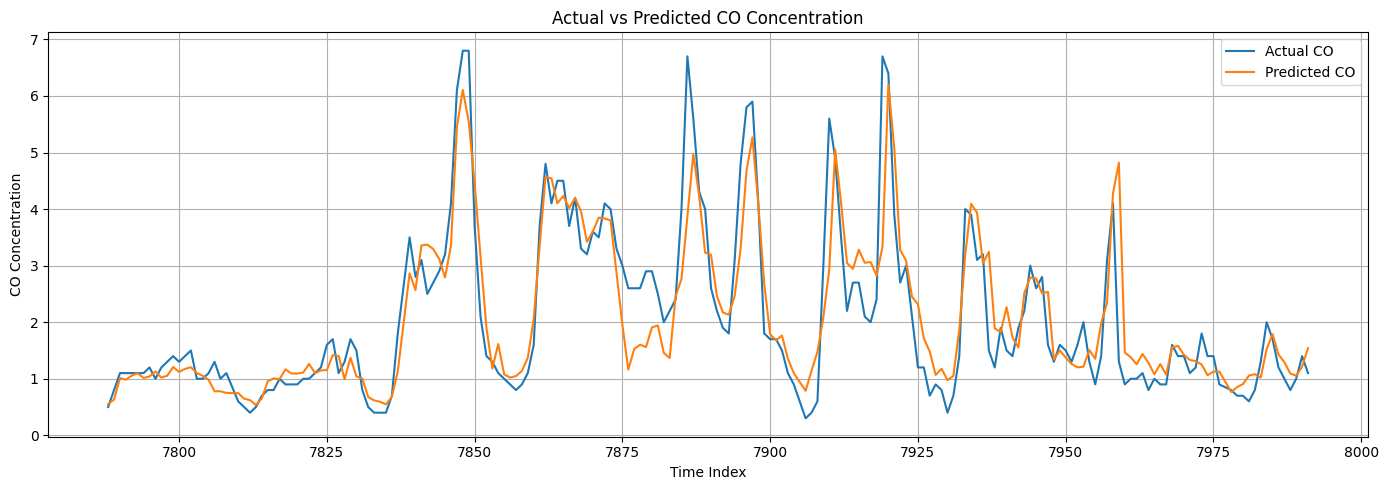

In [25]:
plt.figure(figsize=(14, 5))

plt.plot(
    results.index[:200],
    results["Actual CO"].iloc[:200],
    label="Actual CO",
    linewidth=1.5
)

plt.plot(
    results.index[:200],
    results["Predicted CO"].iloc[:200],
    label="Predicted CO",
    linewidth=1.5
)

plt.title("Actual vs Predicted CO Concentration")
plt.xlabel("Time Index")
plt.ylabel("CO Concentration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

,Feature,Importance
9,C6H6(GT),0.598910
8,PT08.S1(CO),0.078180
10,NOx(GT),0.073682
0,Hour,0.068725
11,NO2(GT),0.024151
12,T,0.021017
4,CO_lag1,0.020842
2,Month,0.018085
13,RH,0.017628
14,AH,0.016081


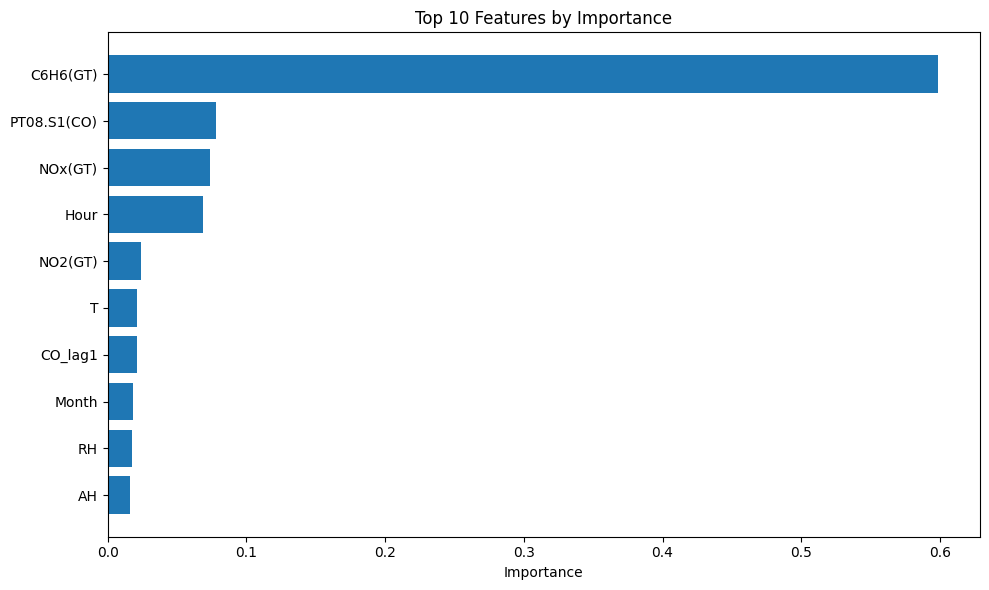

In [26]:
importances = model.named_steps["regressor"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

display(importance_df)

plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"].head(10)[::-1],
    importance_df["Importance"].head(10)[::-1]
)

plt.title("Top 10 Features by Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [27]:
results = pd.DataFrame({
    "Actual CO": y_test,
    "Predicted CO": y_pred
})

results["Error"] = results["Actual CO"] - results["Predicted CO"]

display(results.head(10))

print("Mean prediction error:", round(results["Error"].mean(), 4))
print("Maximum absolute error:", round(results["Error"].abs().max(), 4))

,Actual CO,Predicted CO,Error
7788,0.5,0.553,-0.053
7789,0.8,0.632,0.168
7790,1.1,1.012,0.088
7791,1.1,0.983,0.117
7792,1.1,1.057,0.043
7793,1.1,1.097,0.003
7794,1.1,1.014,0.086
7795,1.2,1.040,0.160
7796,1.0,1.130,-0.130
7797,1.2,1.021,0.179


Mean prediction error: -0.0661
Maximum absolute error: 4.04


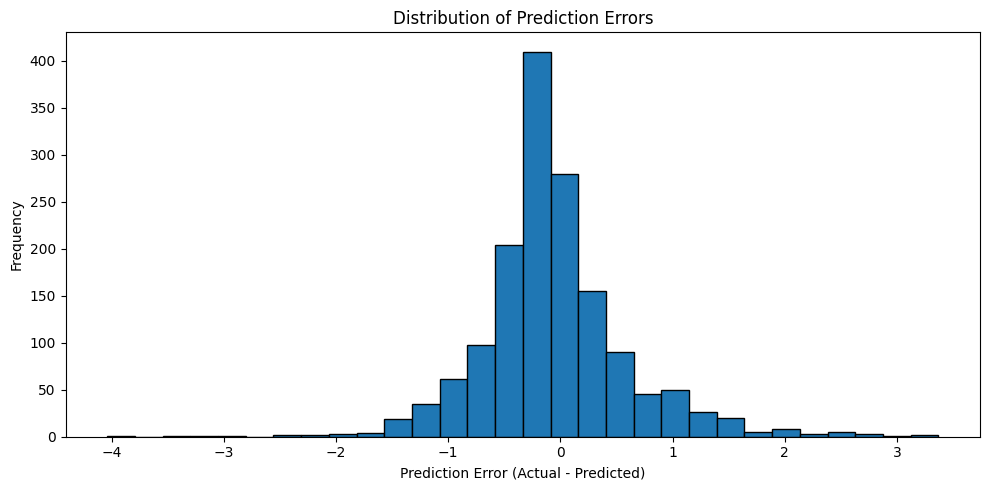

In [28]:
plt.figure(figsize=(10, 5))

plt.hist(results["Error"], bins=30, edgecolor="black")

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Key Findings

1. The dataset contains hourly air quality measurements collected over time.
2. Several measurement columns contain missing values represented by -200.
3. CO concentration varies over time, showing changes across different hours and months.
4. Time-based features such as hour, day, and month help represent temporal patterns.
5. Lag features and rolling averages help capture past CO concentration trends.
6. The Random Forest model predicts the next hour's CO concentration using past measurements and environmental variables.
7. The model's performance is evaluated using MAE, MSE, RMSE, and R².

## Limitations

1. The dataset contains a large number of missing values, especially in the NMHC(GT) column, which may affect model performance.
2. The model is trained on historical data from a single monitoring location, so its predictions may not generalize to other locations.
3. The model uses a limited set of features and may not capture sudden changes in pollution caused by unusual events or weather conditions.

## Conclusion

This project explored air quality data and developed a Random Forest regression model to forecast the next hour's CO concentration. Data cleaning, exploratory data analysis, and feature engineering were performed before training the model. Its performance was evaluated using regression metrics and visualizations. The project provided practical experience in time-series forecasting, data preprocessing, and machine learning.
